In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os

from utils import *
from models import *
from compare import save_metrics

torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True                                                                         
torch.backends.cudnn.benchmark = False

In [2]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [3]:
import_dataset()

Dataset folder already exists, ignoring...


C:\Users\Innam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


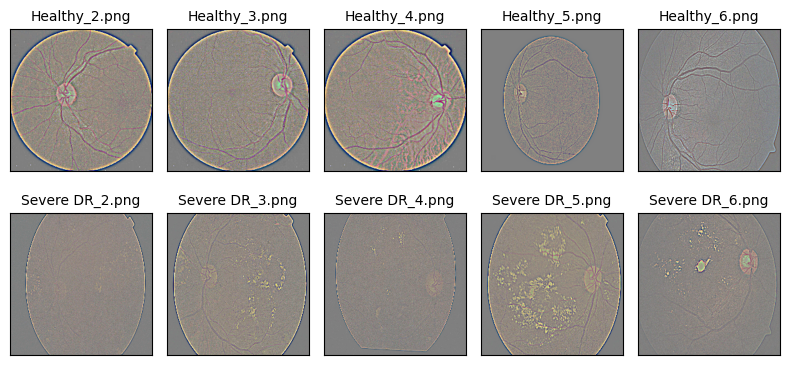

In [4]:
visualize_dataset()

In [5]:
full_dataset = initialize_dataset(transforms.Compose([transforms.ToTensor()]))
train_dataset, test_dataset, validation_dataset = split_dataset(full_dataset)

Classes: {'Healthy': 0, 'Severe DR': 1}
Total dataset size: 1190
Total 'Healthy' samples: 1000
Total 'Severe' samples: 190


In [6]:
from torchvision.ops import sigmoid_focal_loss
from IPython.display import clear_output
import json

batch_sizes = [2**i for i in range(3,7)]
epochs = [i for i in range(20,51,10)]

losses = [nn.CrossEntropyLoss(),
          sigmoid_focal_loss]

metrics = dict()

for i in range(len(batch_sizes)):
    batch_size = batch_sizes[i]
    train_dataloader, test_dataloader, validation_dataloader = initialize_dataloaders(train_dataset, test_dataset, validation_dataset, batch_size=batch_size) 
    for j in range(len(epochs)):
        epoch = epochs[j]
        for k in range(len(losses)):
            criterion = losses[k]
            model = AResUNetClassifier().to(device)
            name = f"{batch_size}_{epoch}_c{k}"
            model._name = name
            print(f"Training model {name}...")
            train_model(model, criterion, train_dataloader, validation_dataloader, device, num_epochs=epoch, save_dir="./outputs/tuning/plots", verbose=False)
            print(f"Evaluating model {name}...")
            metrics[name] = save_metrics(model, train_dataloader, validation_dataloader, test_dataloader, device, eval_dir="./outputs/tuning/out")
            del model
        clear_output()
    with open(f"gridsearch_results.json", "w") as f:
        json.dump(metrics, f, indent=4)

print(f"All models have fully been trained and evaluated!")

All models have fully been trained and evaluated!


In [ ]:
best_train_acc = max(metrics, key=lambda k: metrics[k][0][0])
best_train_f1 = max(metrics, key=lambda k: metrics[k][0][1])
best_train_f2 = max(metrics, key=lambda k: metrics[k][0][2])
best_train_recall = max(metrics, key=lambda k: metrics[k][0][3])

print(f"Best Train Accuracy: {metrics.get(best_train_acc)[0][0]} from {best_train_acc}")
print(f"Best Train F1 Score: {metrics.get(best_train_f1)[0][1]} from {best_train_f1}")
print(f"Best Train F2 Score: {metrics.get(best_train_f2)[0][2]} from {best_train_f2}")
print(f"Best Train Recall: {metrics.get(best_train_recall)[0][3]} from {best_train_recall}\n")

best_validation_acc = max(metrics, key=lambda k: metrics[k][1][0])
best_validation_f1 = max(metrics, key=lambda k: metrics[k][1][1])
best_validation_f2 = max(metrics, key=lambda k: metrics[k][1][2])
best_validation_recall = max(metrics, key=lambda k: metrics[k][1][3])

print(f"Best Validation Accuracy: {metrics.get(best_validation_acc)[1][0]} from {best_validation_acc}")
print(f"Best Validation F1 Score: {metrics.get(best_validation_f1)[1][1]} from {best_validation_f1}")
print(f"Best Validation F2 Score: {metrics.get(best_validation_f2)[1][2]} from {best_validation_f2}")
print(f"Best Validation Recall: {metrics.get(best_validation_recall)[1][3]} from {best_validation_recall}\n")

best_test_acc = max(metrics, key=lambda k: metrics[k][2][0])
best_test_f1 = max(metrics, key=lambda k: metrics[k][2][1])
best_test_f2 = max(metrics, key=lambda k: metrics[k][2][2])
best_test_recall = max(metrics, key=lambda k: metrics[k][2][3])

print(f"Best Test Accuracy: {metrics.get(best_test_acc)[2][0]} from {best_test_acc}")
print(f"Best Test F1 Score: {metrics.get(best_test_f1)[2][1]} from {best_test_f1}")
print(f"Best Test F2 Score: {metrics.get(best_test_f2)[2][2]} from {best_test_f2}")
print(f"Best Test Recall: {metrics.get(best_test_recall)[2][3]} from {best_test_recall}\n")

best_overall_acc = max(metrics, key=lambda k: (metrics[k][0][0], metrics[k][1][0], metrics[k][2][0]))
best_overall_f1 = max(metrics, key=lambda k: (metrics[k][0][1], metrics[k][1][1], metrics[k][2][1]))
best_overall_f2 = max(metrics, key=lambda k: (metrics[k][0][2], metrics[k][1][2], metrics[k][2][2]))
best_overall_recall = max(metrics, key=lambda k: (metrics[k][0][3], metrics[k][1][3], metrics[k][2][3]))

print(f"Best Overall Accuracy: {metrics.get(best_overall_acc)} from {best_overall_acc}")
print(f"Best Overall F1 Score: {metrics.get(best_overall_f1)} from {best_overall_f1}")
print(f"Best Overall F2 Score: {metrics.get(best_overall_f2)} from {best_overall_f2}")
print(f"Best Overall Recall: {metrics.get(best_overall_recall)} from {best_overall_recall}\n")

Best Train Accuracy: 99.68487620353699 from 8_50_c0
Best Train F1 Score: 0.9900332093238831 from 8_50_c0
Best Train F2 Score: 0.9841479063034058 from 8_50_c0
Best Train Recall: 100.0 from 8_30_c0

Best Validation Accuracy: 99.15966987609863 from 8_30_c0
Best Validation F1 Score: 0.9743589162826538 from 8_30_c0
Best Validation F2 Score: 0.9895832538604736 from 8_30_c0
Best Validation Recall: 100.0 from 8_20_c1

Best Test Accuracy: 100.0 from 8_40_c0
Best Test F1 Score: 1.0 from 8_40_c0
Best Test F2 Score: 1.0 from 8_40_c0
Best Test Recall: 100.0 from 8_20_c1

Best Overall Accuracy: ((99.68487620353699, 0.9900332093238831, 0.9841479063034058, 98.02631735801697), (98.31933379173279, 0.9473684430122375, 0.9473684430122375, 94.73684430122375), (100.0, 1.0, 1.0, 100.0)) from 8_50_c0
Best Overall F1 Score: ((99.68487620353699, 0.9900332093238831, 0.9841479063034058, 98.02631735801697), (98.31933379173279, 0.9473684430122375, 0.9473684430122375, 94.73684430122375), (100.0, 1.0, 1.0, 100.0)) fr

In [ ]:
delta = min(metrics, key=lambda k: abs(metrics[k][0][0]-metrics[k][1][0]))
best_overall_model = max(metrics, key=lambda k: (delta, metrics[k][0][0], metrics[k][1][0], metrics[k][2][0], metrics[k][0][1], metrics[k][1][1], metrics[k][2][1], metrics[k][0][2], metrics[k][1][2], metrics[k][2][2]))
print(metrics.get(best_overall_model), best_overall_model)

((99.68487620353699, 0.9900332093238831, 0.9841479063034058, 98.02631735801697), (98.31933379173279, 0.9473684430122375, 0.9473684430122375, 94.73684430122375), (100.0, 1.0, 1.0, 100.0)) 8_50_c0
